# 05 — UCI Heart Disease Dataset Exploratory Data Analysis (EDA)

This notebook performs exploratory data analysis on the UCI Heart Disease dataset to understand its structure, feature distributions, missing values, and relationship with the target variable before preprocessing and cross-dataset validation.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")


In [2]:
uci = pd.read_csv("../data/raw/heart_disease_uci.csv")


In [3]:

print(f"Dataset Shape : {uci.shape}")


Dataset Shape : (920, 16)


In [4]:


uci.head()


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [5]:

uci.info()


<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [6]:

uci.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,920.0,NaN,NaN,NaN,460.5,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,NaN,NaN,NaN,53.51087,9.424685,28.0,47.0,54.0,60.0,77.0
sex,920,2,Male,726,NaN,NaN,NaN,NaN,NaN,NaN,NaN
dataset,920,4,Cleveland,304,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cp,920,4,asymptomatic,496,NaN,NaN,NaN,NaN,NaN,NaN,NaN
trestbps,861.0,NaN,NaN,NaN,132.132404,19.06607,0.0,120.0,130.0,140.0,200.0
chol,890.0,NaN,NaN,NaN,199.130337,110.78081,0.0,175.0,223.0,268.0,603.0
fbs,830,2,False,692,NaN,NaN,NaN,NaN,NaN,NaN,NaN
restecg,918,3,normal,551,NaN,NaN,NaN,NaN,NaN,NaN,NaN
thalch,865.0,NaN,NaN,NaN,137.545665,25.926276,60.0,120.0,140.0,157.0,202.0


In [7]:

missing = pd.DataFrame({
    "Missing Values": uci.isnull().sum(),
    "Percentage": (uci.isnull().mean() * 100).round(2)
})

missing[missing["Missing Values"] > 0].sort_values(
    by="Percentage",
    ascending=False
)


,Missing Values,Percentage
ca,611,66.41
thal,486,52.83
slope,309,33.59
fbs,90,9.78
oldpeak,62,6.74
trestbps,59,6.41
thalch,55,5.98
exang,55,5.98
chol,30,3.26
restecg,2,0.22


In [8]:

print("Duplicate Rows:", uci.duplicated().sum())


Duplicate Rows: 0



## Dataset Overview

The UCI Heart Disease dataset contains patient records collected from multiple hospitals.

Unlike the Mendeley dataset, it includes missing values, additional attributes, and categorical variables represented using textual labels. These differences require preprocessing before the dataset can be used for external validation.


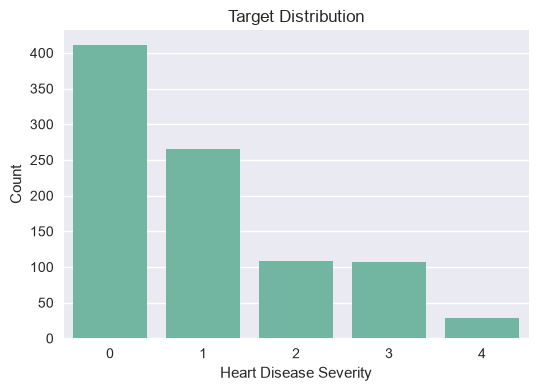

In [9]:


# Target Analysis
plt.figure(figsize=(6,4))

sns.countplot(data=uci, x="num")

plt.title("Target Distribution")
plt.xlabel("Heart Disease Severity")
plt.ylabel("Count")

plt.show()


In [10]:
uci["num"].value_counts().sort_index()


num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64


The target variable contains multiple disease severity levels (0–4), unlike the binary target used in the Mendeley dataset.

This will later be converted into a binary classification problem during preprocessing.


In [11]:


# Numerical Features

numerical_features = uci.select_dtypes(
    include=np.number
).columns

numerical_features


Index(['id', 'age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'ca', 'num'], dtype='str')

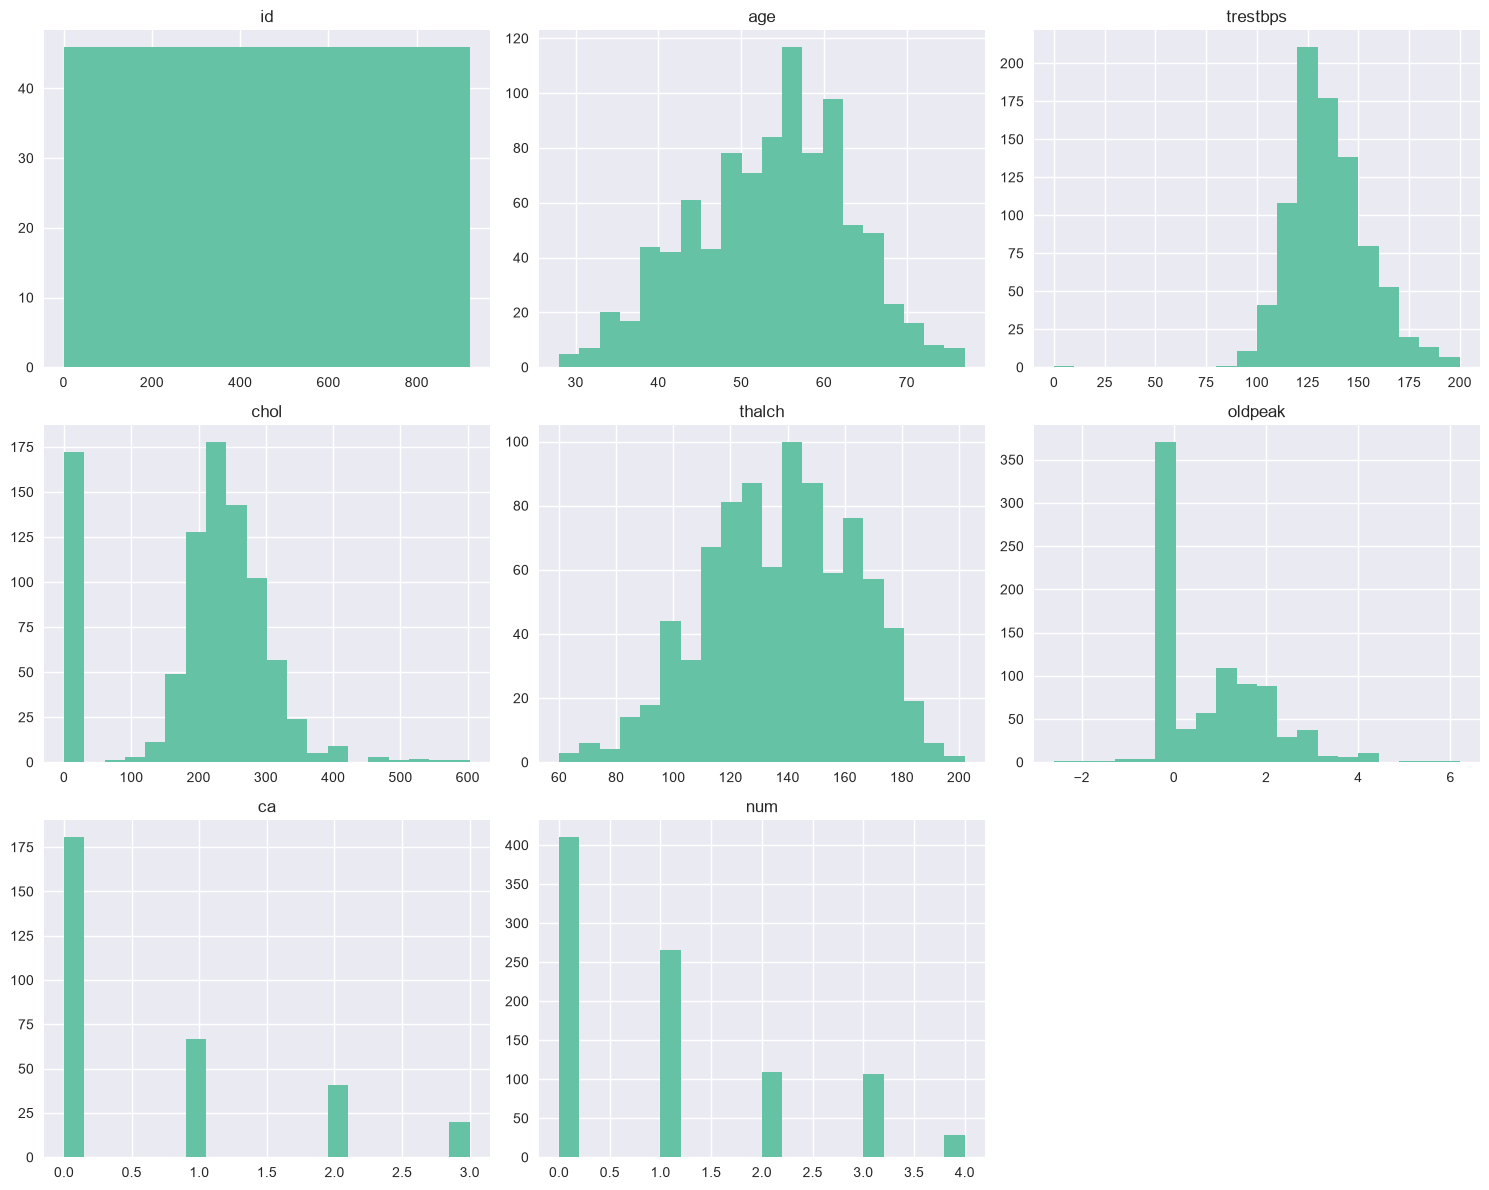

In [12]:
uci[numerical_features].hist(
    figsize=(15,12),
    bins=20
)

plt.tight_layout()
plt.show()


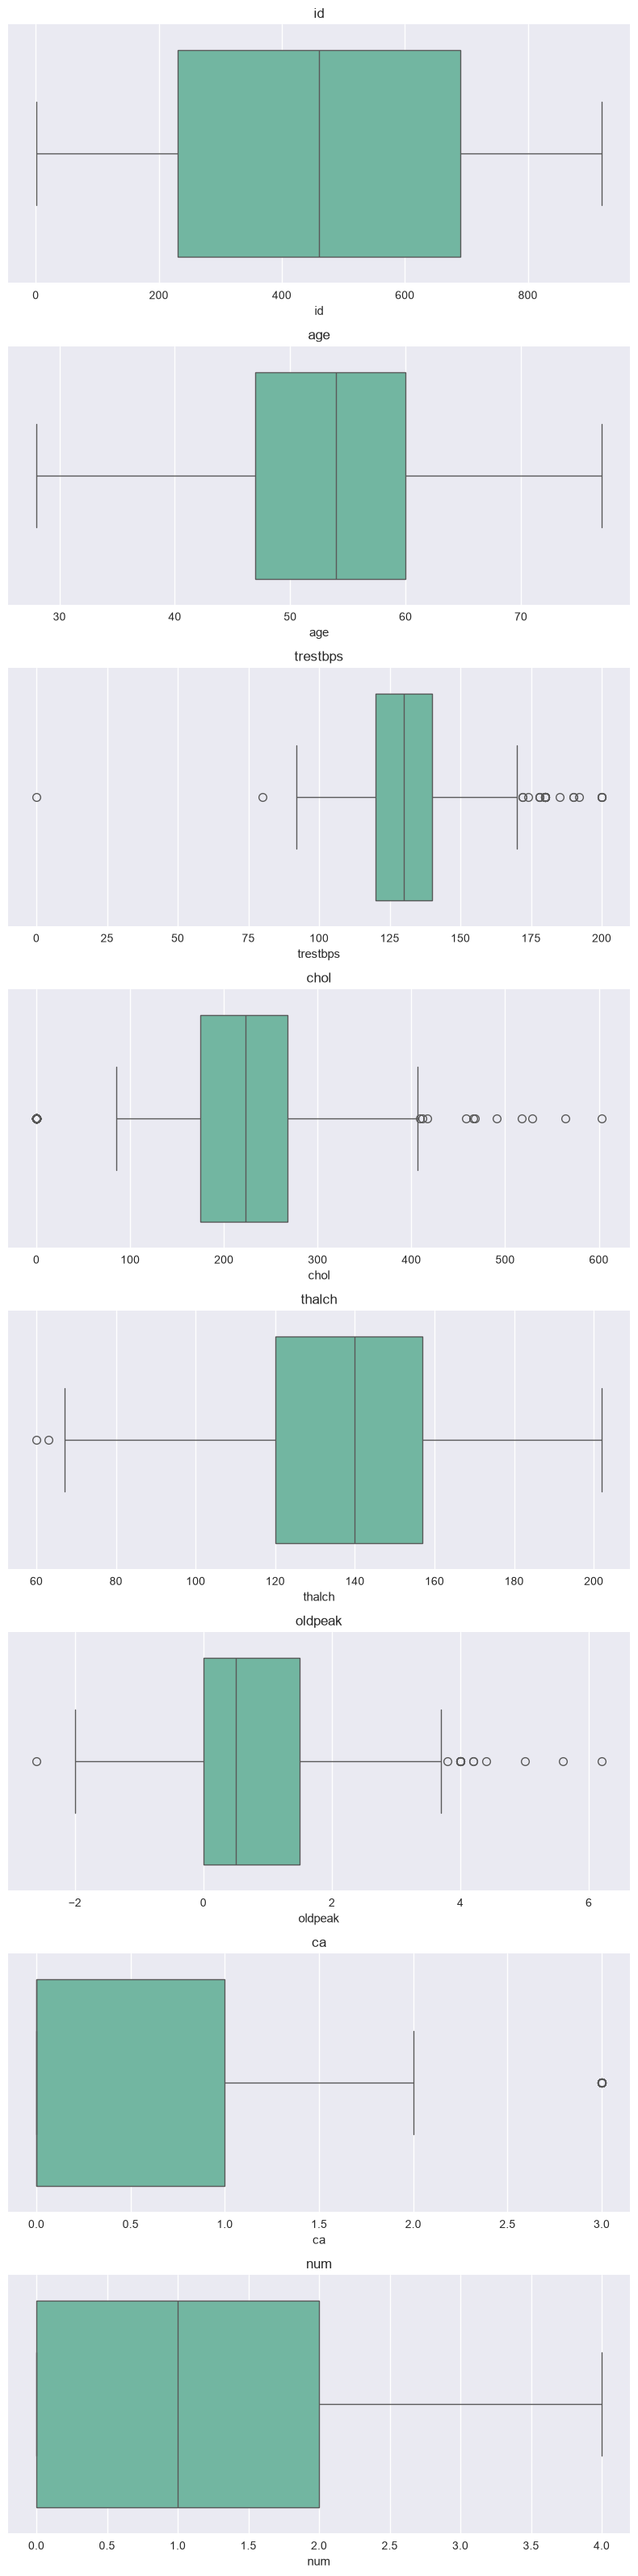

In [13]:

fig, axes = plt.subplots(
    len(numerical_features),
    1,
    figsize=(8,4*len(numerical_features))
)

for ax, col in zip(axes, numerical_features):
    sns.boxplot(data=uci, x=col, ax=ax)
    ax.set_title(col)

plt.tight_layout()
plt.show()


In [14]:
categorical_features = uci.select_dtypes(
    include="object"
).columns

categorical_features


Index(['sex', 'dataset', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], dtype='str')

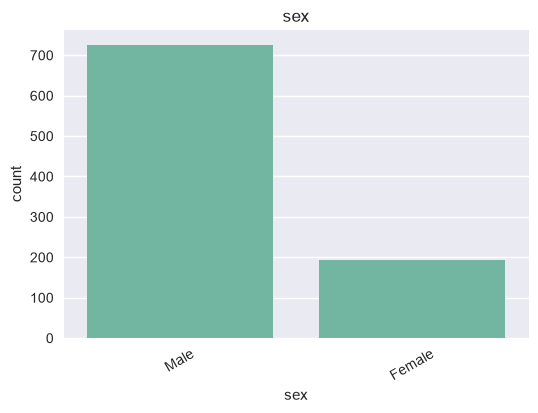

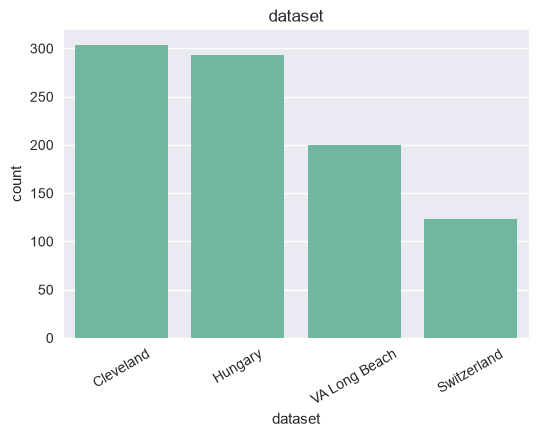

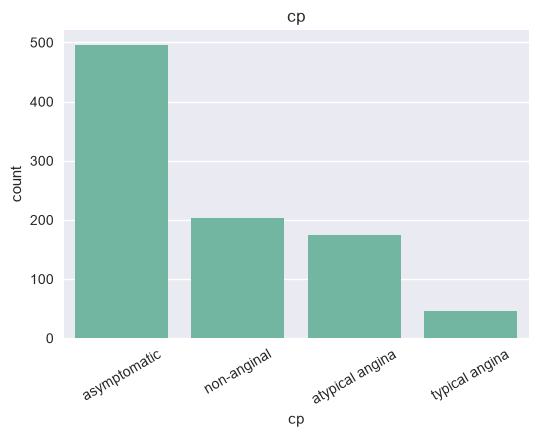

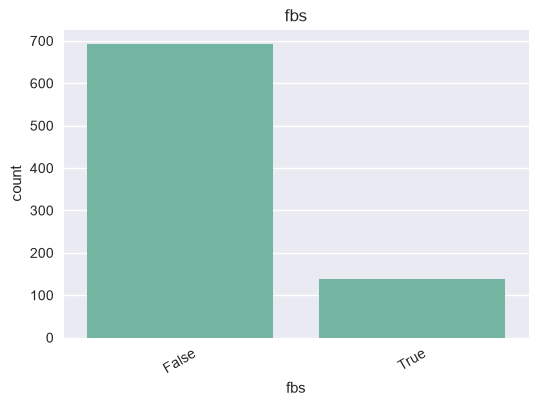

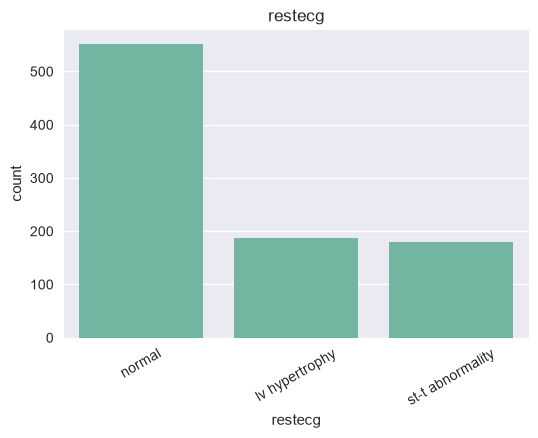

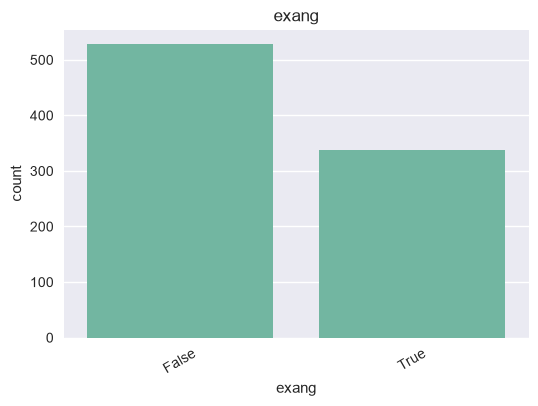

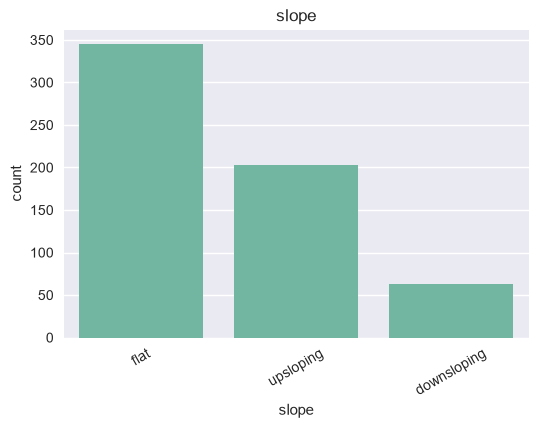

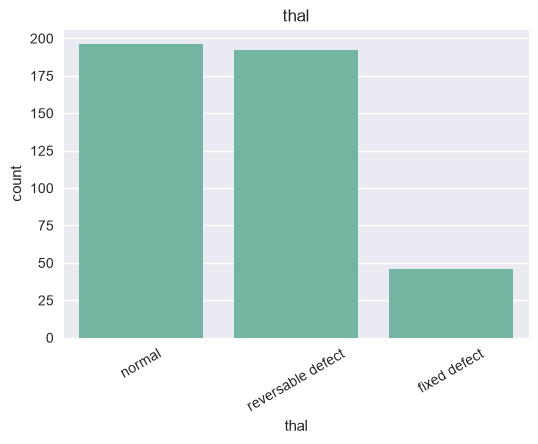

In [15]:
for feature in categorical_features:

    plt.figure(figsize=(6,4))

    sns.countplot(
        data=uci,
        x=feature,
        order=uci[feature].value_counts().index
    )

    plt.title(feature)
    plt.xticks(rotation=30)

    plt.show()



In [16]:

# Numerical vs Target

binary_target = uci["num"].apply(
    lambda x: 0 if x == 0 else 1
)

temp = uci.copy()

temp["target"] = binary_target


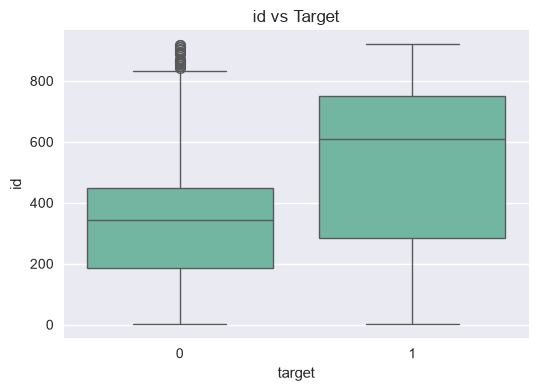

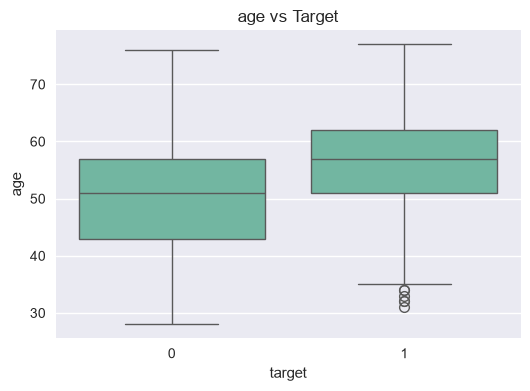

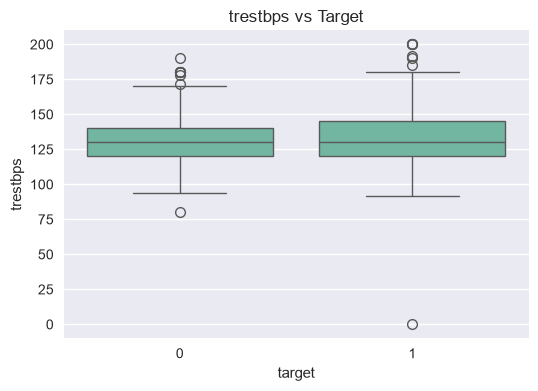

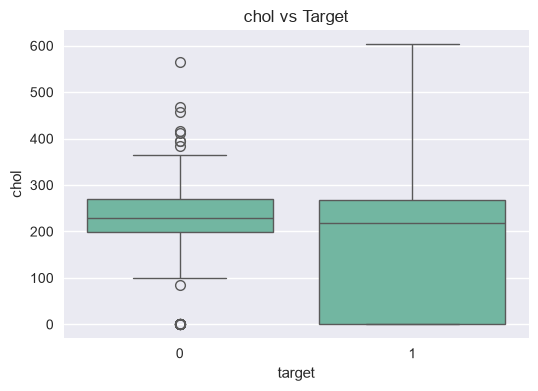

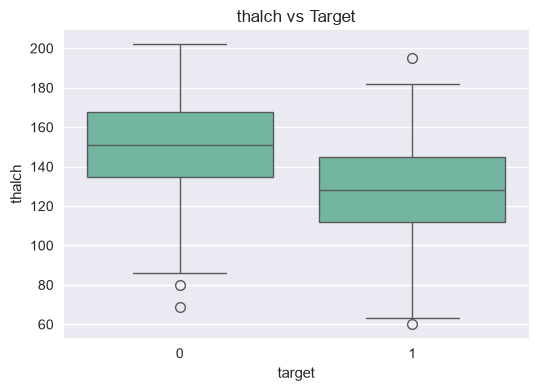

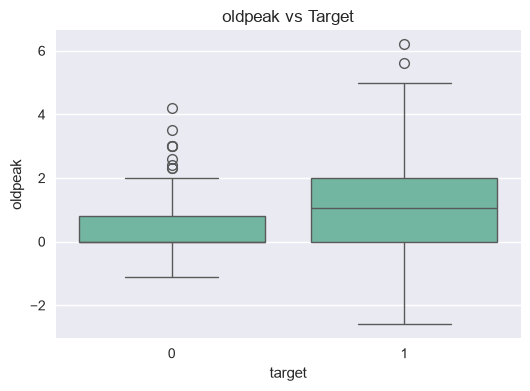

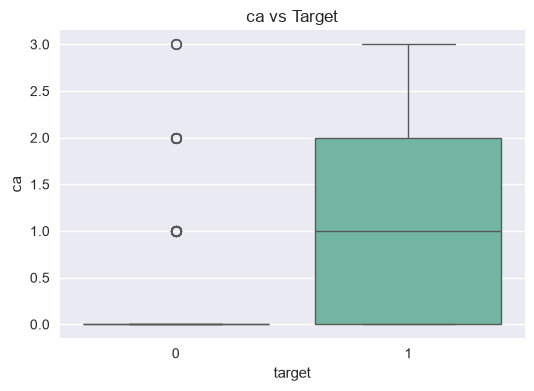

In [17]:

for feature in numerical_features.drop("num"):

    plt.figure(figsize=(6,4))

    sns.boxplot(
        data=temp,
        x="target",
        y=feature
    )

    plt.title(f"{feature} vs Target")

    plt.show()



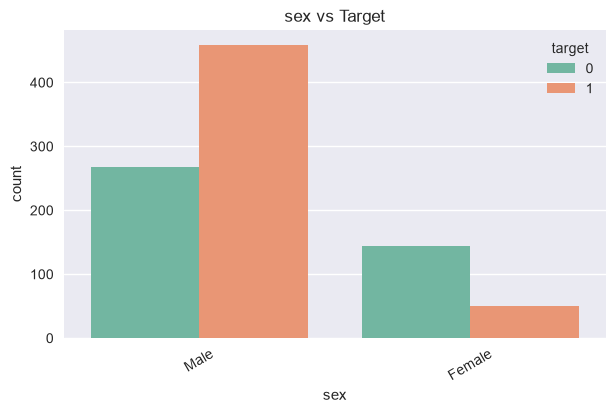

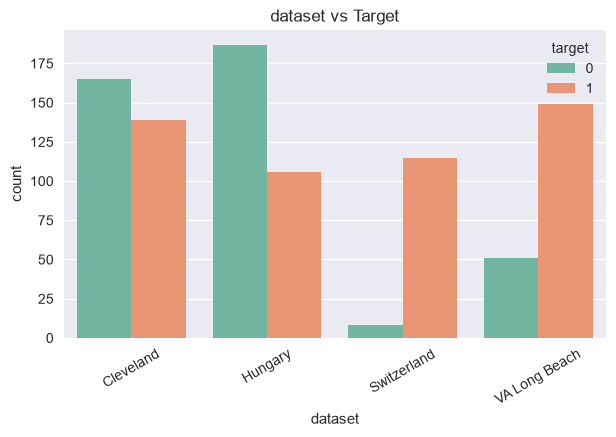

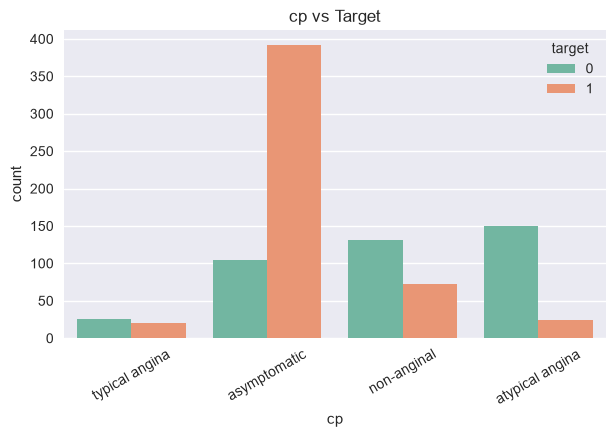

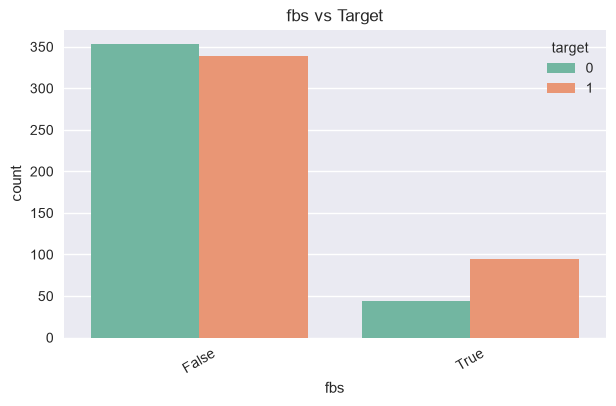

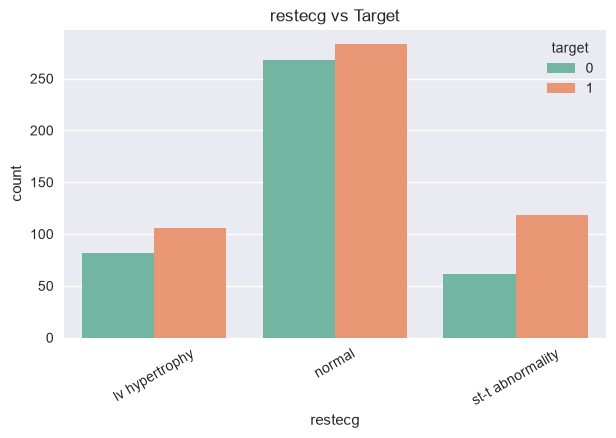

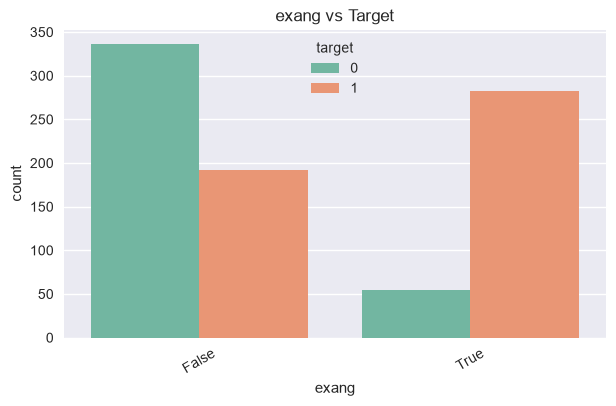

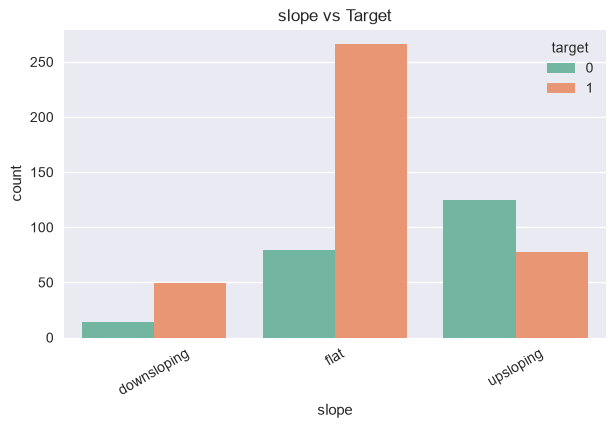

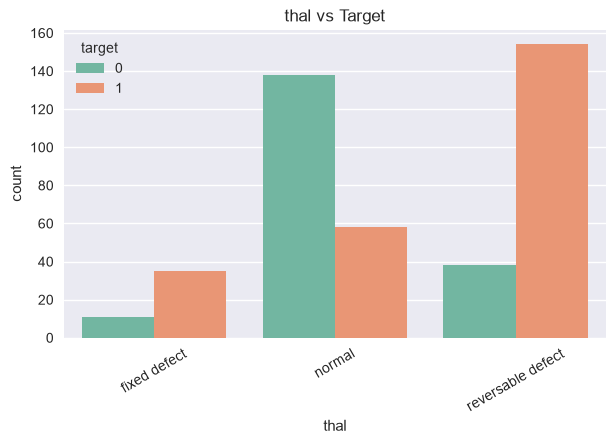

In [18]:

# Categorical vs Target
for feature in categorical_features:

    plt.figure(figsize=(7,4))

    sns.countplot(
        data=temp,
        x=feature,
        hue="target"
    )

    plt.xticks(rotation=30)

    plt.title(f"{feature} vs Target")

    plt.show()



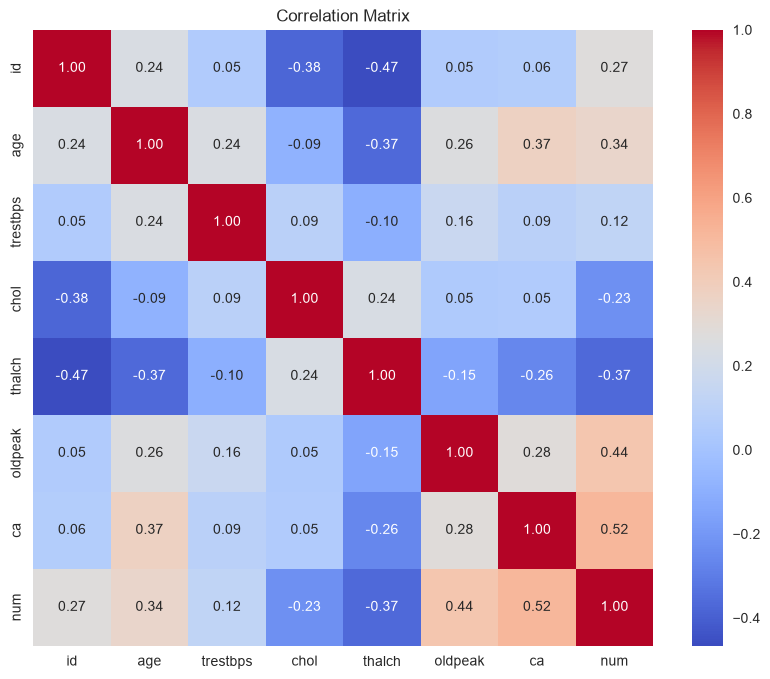

In [19]:


# Correlation

plt.figure(figsize=(10,8))

sns.heatmap(
    temp[numerical_features].corr(),
    cmap="coolwarm",
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()


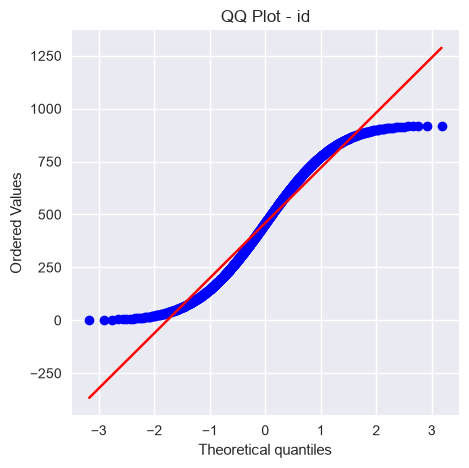

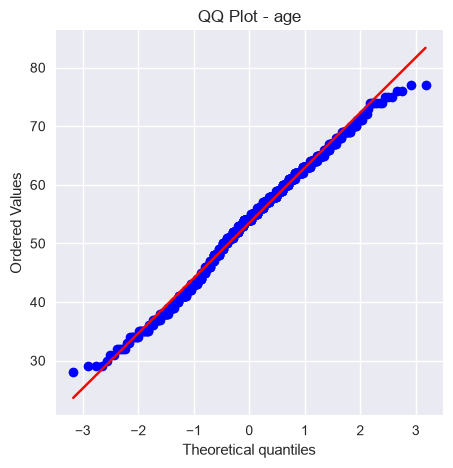

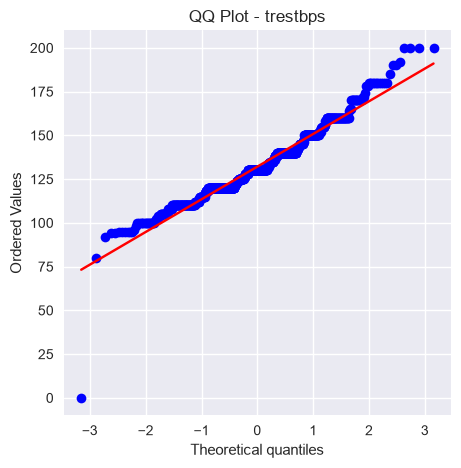

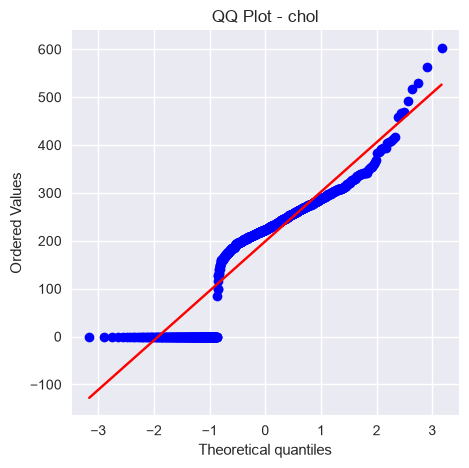

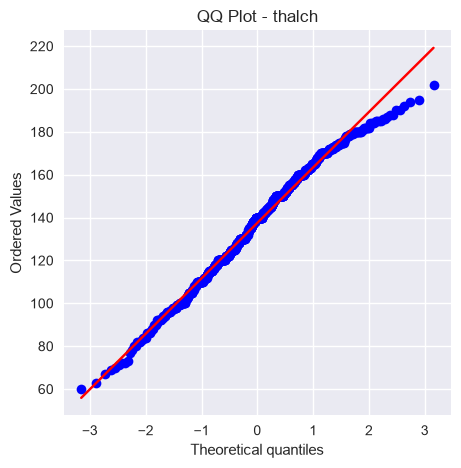

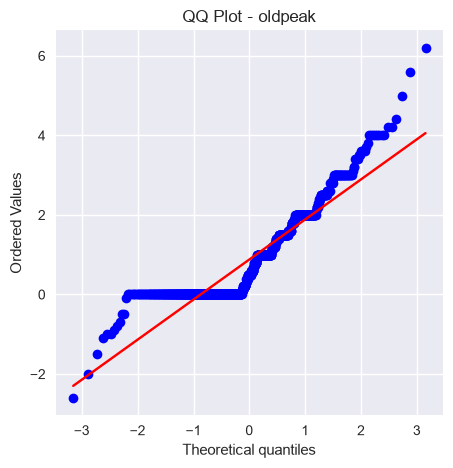

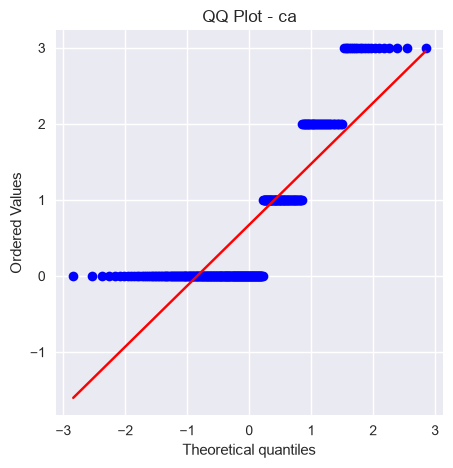

In [20]:


# QQ Plots
for feature in numerical_features.drop("num"):

    plt.figure(figsize=(5,5))

    stats.probplot(
        temp[feature].dropna(),
        dist="norm",
        plot=plt
    )

    plt.title(f"QQ Plot - {feature}")

    plt.show()

In [21]:

# Statistical Analysis
temp.groupby("target")[numerical_features.drop("num")].mean().T

target,0,1
id,355.257908,545.479371
age,50.547445,55.903733
trestbps,129.913043,133.978723
chol,227.905612,176.479920
thalch,148.800512,128.261603
oldpeak,0.418205,1.262607
ca,0.278788,1.131944




## UCI EDA Summary

Key observations from the UCI dataset are:

- The dataset contains missing values that require imputation.
- The target variable is multi-class (0–4) and must be converted into a binary target.
- Several categorical variables are stored as string labels and require encoding.
- Feature names and representations differ from the Mendeley dataset.
- Additional columns are present that are not used in the original CARDIACX pipeline.
- The dataset follows a different distribution compared to the Mendeley dataset, making direct evaluation challenging.

These differences motivate the preprocessing and feature alignment steps performed in the next notebook before cross-dataset validation.
